In [8]:
from dotenv import load_dotenv

_ = load_dotenv()   

In [9]:
from langgraph.graph import StateGraph ,END
from typing import TypedDict,Annotated
import operator
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

In [10]:
class AgentState(TypedDict):
    lnode:str
    scratch:str
    count:Annotated[int,operator.add]

In [11]:
def node1(state: AgentState):
    print(f"node1,count:{state['count']}")
    return {"lnode":"node_1",
            "count":1,
            }

def node2(state: AgentState):
    print(f"node2,count:{state['count']}")
    return{"lnode":"node_2",
           "count": 1,

    }

In [12]:
def should_continue(state):
    return state["count"]<3

In [13]:
builder = StateGraph(AgentState)
builder.add_node("Node1",node1)
builder.add_node("Node2",node2)

builder.add_edge("Node1","Node2")
builder.add_conditional_edges("Node2",should_continue,{True:"Node1",False:END})
builder.set_entry_point("Node1")


In [15]:
graph = builder.compile(checkpointer=memory)

In [18]:
thread = {"configurable":{"thread_id":"1"}}
# for event in graph.stream({"count":0,"scratch":"hi"},thread):
#     for k, v in event.items():
#         print(v)

graph.invoke({"count":0, "scratch":"hi"},thread)

node1,count:3
node2,count:4


{'lnode': 'node_2', 'scratch': 'hi', 'count': 5}

In [19]:
graph.get_state(thread)

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hi', 'count': 5}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b450-62d8-8009-0c8a968e1eba'}}, metadata={'source': 'loop', 'step': 9, 'parents': {}}, created_at='2026-06-06T22:31:10.969724+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b44d-6bbc-8008-1e6bedde432f'}}, tasks=(), interrupts=())

In [22]:
for state in graph.get_state_history(thread):
    print(state,"\n")

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hi', 'count': 5}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b450-62d8-8009-0c8a968e1eba'}}, metadata={'source': 'loop', 'step': 9, 'parents': {}}, created_at='2026-06-06T22:31:10.969724+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b44d-6bbc-8008-1e6bedde432f'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hi', 'count': 4}, next=('Node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b44d-6bbc-8008-1e6bedde432f'}}, metadata={'source': 'loop', 'step': 8, 'parents': {}}, created_at='2026-06-06T22:31:10.968722+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b44b-64b5-8007-6e54dbdeb75f'}}, tasks=(PregelTask(id='10b9ff04-f7fb-428e-42f7-86ebe93a2c48', name='Node2', path=('__pregel_pull

In [23]:
states = []
for state in graph.get_state_history(thread):
    states.append(state.config)
    print(state.config, state.values['count'])

{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b450-62d8-8009-0c8a968e1eba'}} 5
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b44d-6bbc-8008-1e6bedde432f'}} 4
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b44b-64b5-8007-6e54dbdeb75f'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b448-6d92-8006-9695bbf86f64'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f75-9d3c-63d3-8005-2ef7e7d8731c'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f75-9d39-6cba-8004-4612068680de'}} 2
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f75-9d37-659f-8003-db2e95558856'}} 1
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f75-9d34-6e95-8002-8c4c94840d08'}} 1
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkp

In [24]:
states[-3]

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f161f74-fae0-6da1-8001-b85a2207443a'}}

In [25]:
graph.invoke(None, states[-3])

node2,count:1
node1,count:2
node2,count:3


{'lnode': 'node_2', 'scratch': 'hi', 'count': 4}

In [26]:
thread = {"configurable": {"thread_id": str(1)}}
for state in graph.get_state_history(thread):
    print(state.config, state.values['count'])

{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f87-70c1-65ea-8005-63cf074857ac'}} 4
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f87-70be-6e92-8004-d43ea71af2b0'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f87-70bb-69d8-8003-f2130655edf5'}} 2
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f87-70b8-6ffc-8002-cb2d1ddc2086'}} 1
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b450-62d8-8009-0c8a968e1eba'}} 5
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b44d-6bbc-8008-1e6bedde432f'}} 4
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b44b-64b5-8007-6e54dbdeb75f'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f76-b448-6d92-8006-9695bbf86f64'}} 3
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkp

In [27]:
thread = {"configurable": {"thread_id": str(1)}}
for state in graph.get_state_history(thread):
    print(state,"\n")

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f87-70c1-65ea-8005-63cf074857ac'}}, metadata={'source': 'loop', 'step': 5, 'parents': {}}, created_at='2026-06-06T22:38:40.226045+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f87-70be-6e92-8004-d43ea71af2b0'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hi', 'count': 3}, next=('Node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f87-70be-6e92-8004-d43ea71af2b0'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-06-06T22:38:40.225038+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f161f87-70bb-69d8-8003-f2130655edf5'}}, tasks=(PregelTask(id='ac01c1d4-36b9-aa7f-c604-8af608f5c01b', name='Node2', path=('__pregel_pull

In [28]:
thread2 = {"configurable": {"thread_id": str(2)}}
graph.invoke({"count":0, "scratch":"hi"},thread2)

node1,count:0
node2,count:1
node1,count:2
node2,count:3


{'lnode': 'node_2', 'scratch': 'hi', 'count': 4}

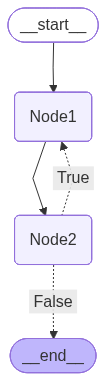

In [33]:
from IPython.display import Image,display

display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
states2 = []
for state in graph.get_state_history(thread2):
    states2.append(state.config)
    print(state.config, state.values['count'])   

{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a83a-600f-8004-0279287117ac'}} 4
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a837-68e8-8003-1682e2e32256'}} 3
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a837-68e7-8002-86493acf7289'}} 2
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a835-622f-8001-e55825b17882'}} 1
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a832-6ad3-8000-0b4796b295b4'}} 0
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a830-63ca-bfff-407fe96bc5ef'}} 0


In [35]:
save_state = graph.get_state(states2[-3])
save_state

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hi', 'count': 1}, next=('Node2',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a835-622f-8001-e55825b17882'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-06T22:43:14.476087+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a832-6ad3-8000-0b4796b295b4'}}, tasks=(PregelTask(id='70832315-7086-2ba7-c956-7e8dbe93e2bb', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result={'lnode': 'node_2', 'count': 1}),), interrupts=())

In [36]:
save_state.values["count"] = -3
save_state.values["scratch"] = "hello"
save_state

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': -3}, next=('Node2',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a835-622f-8001-e55825b17882'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-06-06T22:43:14.476087+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a832-6ad3-8000-0b4796b295b4'}}, tasks=(PregelTask(id='70832315-7086-2ba7-c956-7e8dbe93e2bb', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result={'lnode': 'node_2', 'count': 1}),), interrupts=())

In [37]:
graph.update_state(thread2,save_state.values)

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f162023-57c9-6fea-8005-6768d6ed2f3e'}}

In [38]:
for i, state in enumerate(graph.get_state_history(thread2)):
    if i >= 3:  #print latest 3
        break
    print(state, '\n')

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': 1}, next=('Node1',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162023-57c9-6fea-8005-6768d6ed2f3e'}}, metadata={'source': 'update', 'step': 5, 'parents': {}}, created_at='2026-06-06T23:48:25.201252+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a83a-600f-8004-0279287117ac'}}, tasks=(PregelTask(id='ad4d2d32-7d05-9240-2673-6110381a24cc', name='Node1', path=('__pregel_pull', 'Node1'), error=None, interrupts=(), state=None, result=None),), interrupts=()) 

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hi', 'count': 4}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f161f91-a83a-600f-8004-0279287117ac'}}, metadata={'source': 'loop', 'step': 4, 'parents': {}}, created_at='2026-06-06T22:43:14.478081+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': 

In [39]:
graph.update_state(thread2,save_state.values, as_node="Node1")

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f162025-05fb-6ad7-8006-4cfd13195e67'}}

In [40]:
for i, state in enumerate(graph.get_state_history(thread2)):
    if i >= 3:  #print latest 3
        break
    print(state, '\n')

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': -2}, next=('Node2',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162025-05fb-6ad7-8006-4cfd13195e67'}}, metadata={'source': 'update', 'step': 6, 'parents': {}}, created_at='2026-06-06T23:49:10.310370+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162023-57c9-6fea-8005-6768d6ed2f3e'}}, tasks=(PregelTask(id='9acd994f-da74-fe2a-da84-e3a058b81382', name='Node2', path=('__pregel_pull', 'Node2'), error=None, interrupts=(), state=None, result=None),), interrupts=()) 

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': 1}, next=('Node1',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162023-57c9-6fea-8005-6768d6ed2f3e'}}, metadata={'source': 'update', 'step': 5, 'parents': {}}, created_at='2026-06-06T23:48:25.201252+00:00', parent_config={'configurable': {'thread_id': '2', 'ch

In [41]:
graph.invoke(None,thread2)

node2,count:-2
node1,count:-1
node2,count:0
node1,count:1
node2,count:2


{'lnode': 'node_2', 'scratch': 'hello', 'count': 3}

In [42]:
for state in graph.get_state_history(thread2):
    print(state,"\n")

StateSnapshot(values={'lnode': 'node_2', 'scratch': 'hello', 'count': 3}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162025-fe6b-6876-800b-efcd772e2958'}}, metadata={'source': 'loop', 'step': 11, 'parents': {}}, created_at='2026-06-06T23:49:36.360869+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162025-fe68-6fe9-800a-e879e863d956'}}, tasks=(), interrupts=()) 

StateSnapshot(values={'lnode': 'node_1', 'scratch': 'hello', 'count': 2}, next=('Node2',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162025-fe68-6fe9-800a-e879e863d956'}}, metadata={'source': 'loop', 'step': 10, 'parents': {}}, created_at='2026-06-06T23:49:36.359831+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f162025-fe66-68d4-8009-d81dd172e31d'}}, tasks=(PregelTask(id='4270de70-ab48-48bc-ca4b-84ee71fa754e', name='Node2', path=('__pre